# SMITH regulatory-activity preservation

This notebook reads the exact five-run summary produced by the C. elegans regulatory-activity workflow. It compares SMITH and baselines across the reported cell-identity and developmental-time metrics.

[Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/regulatory_section/02_SMITH_Regulatory_Activity_source.ipynb)

## Provenance

The code cell verifies the SHA-256 of every bundled result table. These files are copied from completed paper-workspace runs; they are not synthetic replacements for the manuscript outputs.

In [1]:
from pathlib import Path
import hashlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

def verify_fixture(relative_path, expected_sha256):
    path = ROOT / "reproducibility" / relative_path
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    assert digest == expected_sha256, f"Checksum mismatch for {path}: {digest}"
    print(f"Verified {relative_path} ({digest[:12]}...)")
    return path


## Analysis

Verified fixtures/elegans_five_run_results_summary.csv (0a6f4d3fbc75...)


,dataset,method,celltype_accuracy,time_pearson
0,elegans_mirna,SMITH_local_refine_round13_trial0022_validated,0.402910,0.972761
2,elegans_mirna,SMITH_overlap_guarded_v1_live_validated,0.399477,0.967818
1,elegans_mirna,SMITH_overlap_guarded_postfix_validated,0.389409,0.959100
9,elegans_tf,SMITH_multi_panel_trial0013_validated,0.613188,0.915390
10,elegans_tf,SMITH_overlap_guarded_postfix_validated,0.593566,0.888825
11,elegans_tf,SMITH_overlap_guarded_v1_live_validated,0.584984,0.884105


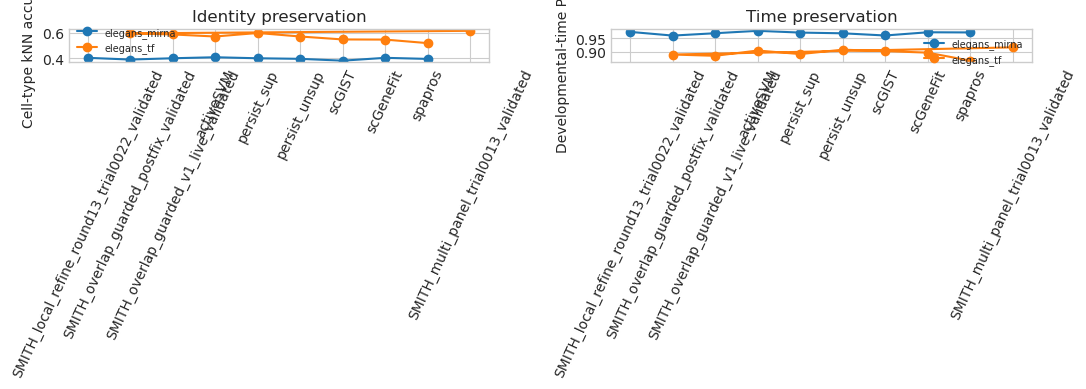

In [2]:
path = verify_fixture("fixtures/elegans_five_run_results_summary.csv", "0a6f4d3fbc75057b58f5dcd9271dbf0f426ba93f4b97274d59fdc0d6b152d01d")
df = pd.read_csv(path)
summary = (df.groupby(["dataset", "method"], as_index=False)
             .agg(celltype_accuracy=("celltype_knn_accuracy_mean", "max"),
                  time_pearson=("time_knn_pearson_mean", "max")))
smith = summary[summary["method"].str.startswith("SMITH")].sort_values(["dataset", "celltype_accuracy"], ascending=[True, False])
display(smith)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for dataset, group in summary.groupby("dataset"):
    axes[0].plot(group["method"], group["celltype_accuracy"], marker="o", label=dataset)
    axes[1].plot(group["method"], group["time_pearson"], marker="o", label=dataset)
for ax, ylabel, title in zip(axes, ["Cell-type kNN accuracy", "Developmental-time Pearson r"], ["Identity preservation", "Time preservation"]):
    ax.set_ylabel(ylabel); ax.set_title(title); ax.tick_params(axis="x", rotation=65); ax.legend(frameon=False, fontsize=7)
fig.tight_layout(); plt.show()


## Scope

The bundled CSV is a real completed five-run output. Re-running Figure 3 from raw atlas data still requires the source datasets, activity inference, donor-aware splits and baseline workflows. The exact generation scripts are archived under `reproducibility/workflows/regulatory_activity/`.